# 1. ENVIRONMENT SETUP AND IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. DATA LOADING AND EXPLORATION

Dataset Shapes:
Users: (1340, 5)
Flights: (271888, 10)
Hotels: (40552, 8)

USERS DATASET - First 5 Rows
   code company             name  gender  age
0     0    4You        Roy Braun    male   21
1     1    4You   Joseph Holsten    male   37
2     2    4You    Wilma Mcinnis  female   48
3     3    4You     Paula Daniel  female   23
4     4    4You  Patricia Carson  female   44

Gender Distribution
gender
male      452
female    448
none      440
Name: count, dtype: int64

Gender Proportions:
gender
male      0.337313
female    0.334328
none      0.328358
Name: proportion, dtype: float64


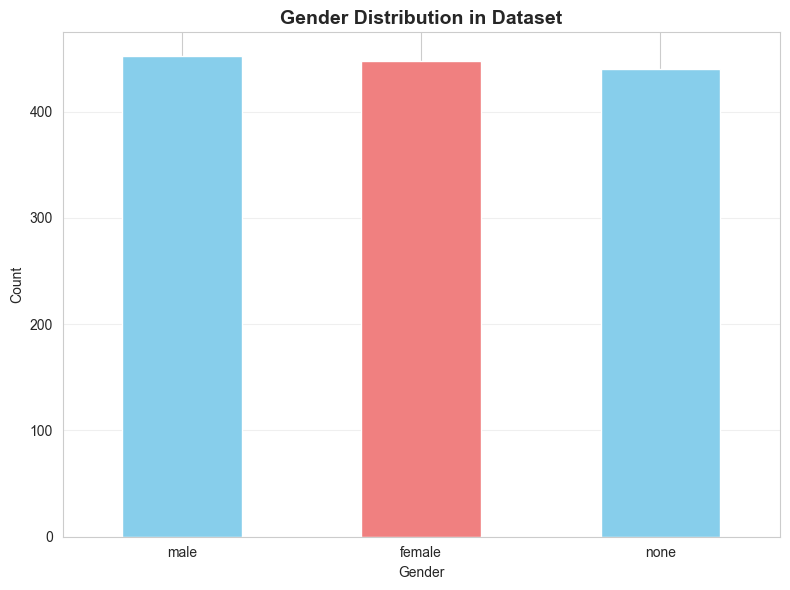

In [2]:
# Load datasets
users_df = pd.read_csv('../data/users.csv')
flights_df = pd.read_csv('../data/flights.csv')
hotels_df = pd.read_csv('../data/hotels.csv')

print("Dataset Shapes:")
print(f"Users: {users_df.shape}")
print(f"Flights: {flights_df.shape}")
print(f"Hotels: {hotels_df.shape}")

print("\n" + "="*80)
print("USERS DATASET - First 5 Rows")
print("="*80)
print(users_df.head())

print("\n" + "="*80)
print("Gender Distribution")
print("="*80)
print(users_df['gender'].value_counts())
print(f"\nGender Proportions:\n{users_df['gender'].value_counts(normalize=True)}")

# Visualize gender distribution
plt.figure(figsize=(8, 6))
users_df['gender'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Gender Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. FEATURE ENGINEERING - COMBINING DATASETS

In [3]:
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Merge datasets
flights_with_users = flights_df.merge(
    users_df, left_on='userCode', right_on='code', how='left'
)

hotels_with_users = hotels_df.merge(
    users_df, left_on='userCode', right_on='code', how='left'
)

# Aggregate flight features per user
flight_features = flights_df.groupby('userCode').agg({
    'price': ['mean', 'sum', 'count', 'std'],
    'time': ['mean', 'sum'],
    'distance': ['mean', 'sum', 'max'],
}).reset_index()

flight_features.columns = [
    'userCode', 'avg_flight_price', 'total_flight_spent',
    'num_flights', 'std_flight_price',
    'avg_flight_time', 'total_flight_time',
    'avg_distance', 'total_distance', 'max_distance'
]

# Aggregate hotel features per user
hotel_features = hotels_df.groupby('userCode').agg({
    'price': ['mean', 'sum'],
    'days': ['mean', 'sum'],
    'total': ['mean', 'sum', 'count']
}).reset_index()

hotel_features.columns = [
    'userCode', 'avg_hotel_price', 'total_hotel_price',
    'avg_hotel_days', 'total_hotel_days',
    'avg_hotel_total', 'total_hotel_spent', 'num_hotel_bookings'
]

# Flight type preferences
flight_type_pivot = pd.crosstab(
    flights_df['userCode'], flights_df['flightType']
)
flight_type_pivot = flight_type_pivot.add_prefix('flightType_').reset_index()

# Agency preferences
agency_counts = flights_df.groupby('userCode')['agency'].agg(
    lambda x: x.value_counts().index[0] if len(x) > 0 else 'Unknown'
).reset_index()
agency_counts.columns = ['userCode', 'preferred_agency']

# Merge all features with users
df = users_df.copy()

df = df.merge(flight_features, left_on='code', right_on='userCode', how='left')
df = df.drop(columns=['userCode'])

df = df.merge(hotel_features, left_on='code', right_on='userCode', how='left')
df = df.drop(columns=['userCode'])

df = df.merge(flight_type_pivot, left_on='code', right_on='userCode', how='left')
df = df.drop(columns=['userCode'])

df = df.merge(agency_counts, left_on='code', right_on='userCode', how='left')
df = df.drop(columns=['userCode'])

# Fill missing values
df = df.fillna(0)

print(f"\nCombined Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Create additional features
df['total_travel_spent'] = df['total_flight_spent'] + df['total_hotel_spent']
df['avg_trip_value'] = df['total_travel_spent'] / (df['num_flights'] + 1)
df['flight_to_hotel_ratio'] = df['num_flights'] / (df['num_hotel_bookings'] + 1)
df['avg_stay_length'] = df['total_hotel_days'] / (df['num_hotel_bookings'] + 1)

# Age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['18-25', '26-35', '36-50', '50+']
)

print("\nNew Features Created Successfully!")



FEATURE ENGINEERING

Combined Dataset Shape: (1340, 25)

Columns: ['code', 'company', 'name', 'gender', 'age', 'avg_flight_price', 'total_flight_spent', 'num_flights', 'std_flight_price', 'avg_flight_time', 'total_flight_time', 'avg_distance', 'total_distance', 'max_distance', 'avg_hotel_price', 'total_hotel_price', 'avg_hotel_days', 'total_hotel_days', 'avg_hotel_total', 'total_hotel_spent', 'num_hotel_bookings', 'flightType_economic', 'flightType_firstClass', 'flightType_premium', 'preferred_agency']

New Features Created Successfully!


# 4. EXPLORATORY DATA ANALYSIS BY GENDER


GENDER-BASED ANALYSIS


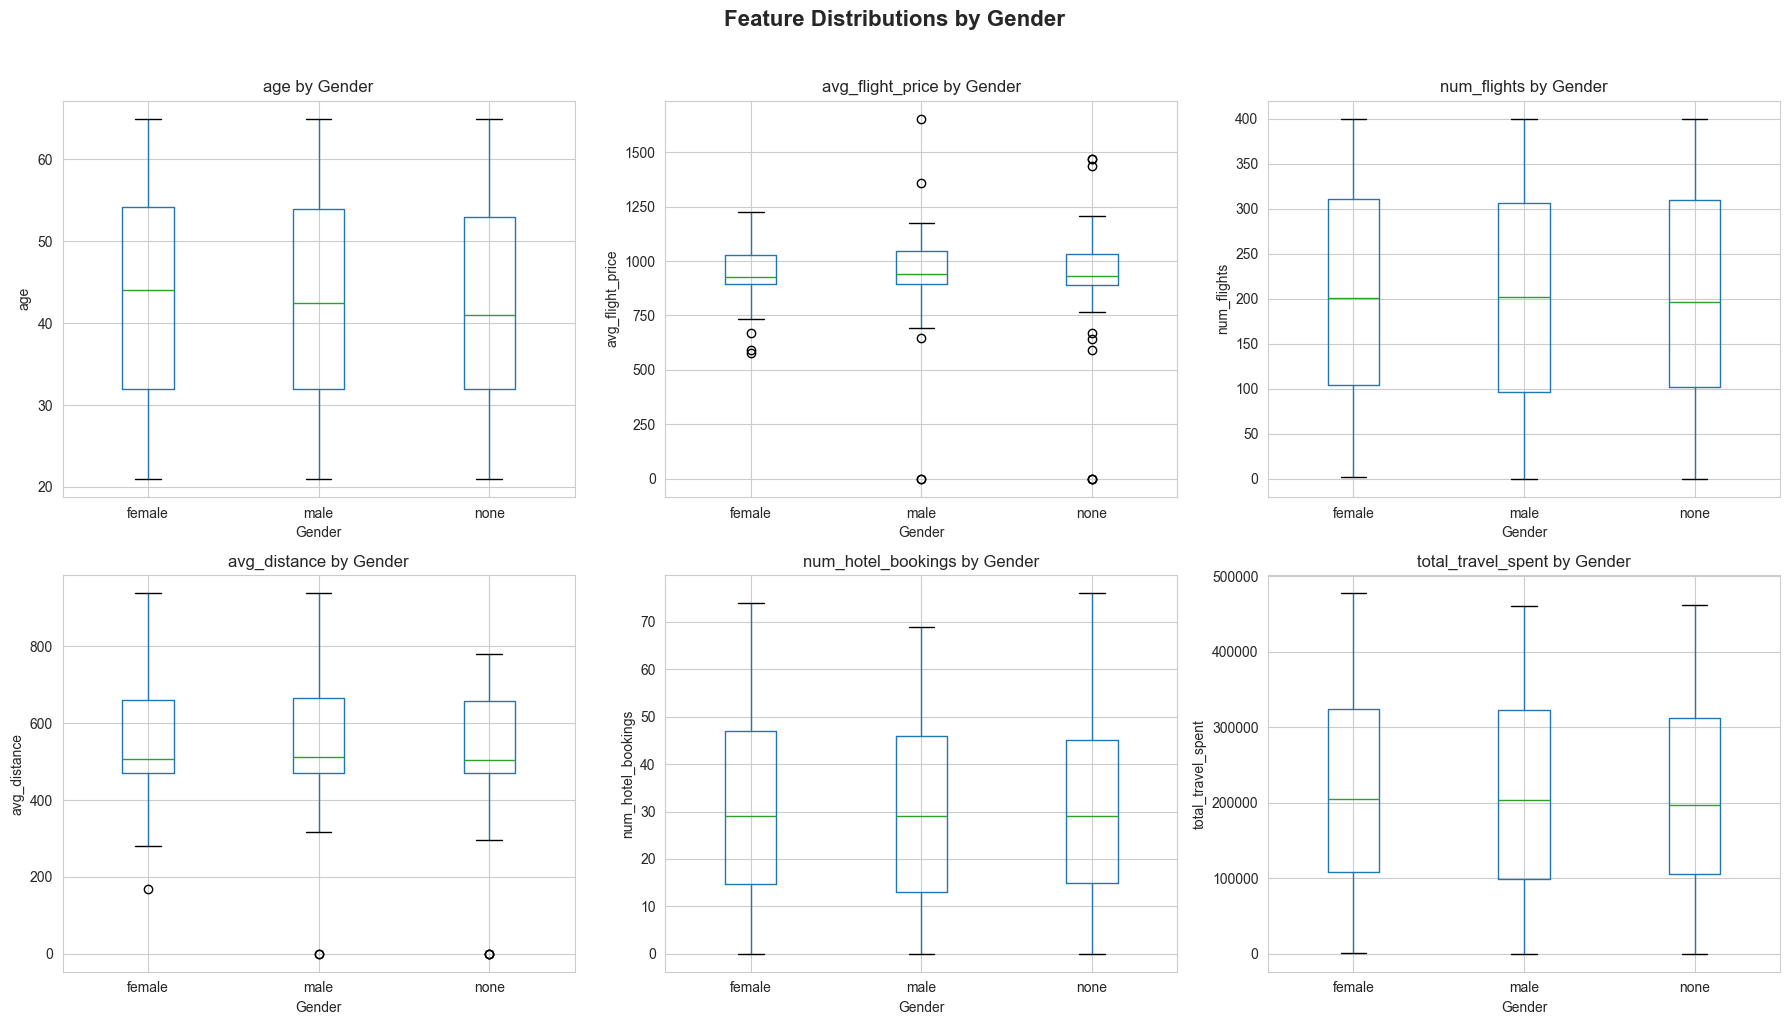


Mean Values by Gender:
              age  avg_flight_price  num_flights  avg_distance  \
gender                                                           
female  43.180804        951.767239   204.419643    545.020673   
male    42.703540        958.225946   201.876106    549.313225   
none    42.336364        948.280540   202.409091    539.292875   

        num_hotel_bookings  total_travel_spent  
gender                                          
female           30.558036       211910.635089  
male             30.055310       210145.763850  
none             30.175000       209368.435386  


In [4]:
print("\n" + "="*80)
print("GENDER-BASED ANALYSIS")
print("="*80)

# Numeric features comparison
numeric_cols = ['age', 'avg_flight_price', 'num_flights', 'avg_distance',
                'num_hotel_bookings', 'total_travel_spent']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='gender', ax=axes[idx])
    axes[idx].set_title(f'{col} by Gender')
    axes[idx].set_xlabel('Gender')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks(rotation=0)

plt.suptitle('Feature Distributions by Gender', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistical comparison
print("\nMean Values by Gender:")
print(df.groupby('gender')[numeric_cols].mean())

# 5. DATA PREPARATION FOR MODELING


In [5]:
print("\n" + "="*80)
print("DATA PREPARATION")
print("="*80)

# Select features for modeling
feature_cols = [
    'age', 'avg_flight_price', 'total_flight_spent', 'num_flights', 
    'std_flight_price', 'avg_flight_time', 'total_flight_time',
    'avg_distance', 'total_distance', 'max_distance',
    'avg_hotel_price', 'total_hotel_price', 'avg_hotel_days', 
    'total_hotel_days', 'num_hotel_bookings',
    'total_travel_spent', 'avg_trip_value', 'flight_to_hotel_ratio',
    'avg_stay_length'
]

# Add flight type columns
flight_type_cols = [col for col in df.columns if col.startswith('flightType_')]
feature_cols.extend(flight_type_cols)

# Encode company and preferred agency
le_company = LabelEncoder()
le_agency = LabelEncoder()

df['company_encoded'] = le_company.fit_transform(df['company'].astype(str))
df['preferred_agency_encoded'] = le_agency.fit_transform(df['preferred_agency'].astype(str))

feature_cols.extend(['company_encoded', 'preferred_agency_encoded'])

# Prepare X and y
X = df[feature_cols].fillna(0)
y = df['gender']

# Encode target variable
le_gender = LabelEncoder()
y_encoded = le_gender.fit_transform(y)

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y_encoded.shape}")
print(f"\nClass Distribution: {np.bincount(y_encoded)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save preprocessing objects
joblib.dump(scaler, 'gender_scaler.pkl')
joblib.dump(le_gender, 'gender_label_encoder.pkl')
joblib.dump(le_company, 'company_encoder.pkl')
joblib.dump(le_agency, 'agency_encoder.pkl')
print("\nPreprocessing objects saved!")


DATA PREPARATION

Feature Matrix Shape: (1340, 24)
Target Vector Shape: (1340,)

Class Distribution: [448 452 440]

Training Set: (1072, 24)
Testing Set: (268, 24)

Preprocessing objects saved!


# 6. MODEL TRAINING AND EVALUATION


MODEL TRAINING AND EVALUATION

Training Logistic Regression...
  Train Accuracy: 0.3918
  Test Accuracy: 0.3396
  Precision: 0.3418
  Recall: 0.3396
  F1 Score: 0.3395
  ROC AUC: 0.5086

Training Random Forest...
  Train Accuracy: 1.0000
  Test Accuracy: 0.3358
  Precision: 0.3367
  Recall: 0.3358
  F1 Score: 0.3350
  ROC AUC: 0.4959

Training Gradient Boosting...
  Train Accuracy: 0.8619
  Test Accuracy: 0.3396
  Precision: 0.3395
  Recall: 0.3396
  F1 Score: 0.3390
  ROC AUC: 0.5079

Training SVM...
  Train Accuracy: 0.4869
  Test Accuracy: 0.2910
  Precision: 0.2882
  Recall: 0.2910
  F1 Score: 0.2885
  ROC AUC: 0.5084

Training Naive Bayes...
  Train Accuracy: 0.3591
  Test Accuracy: 0.3246
  Precision: 0.3050
  Recall: 0.3246
  F1 Score: 0.2946
  ROC AUC: 0.4787

MODEL COMPARISON
                     Train Accuracy  Test Accuracy  Precision    Recall  \
Logistic Regression        0.391791       0.339552   0.341800  0.339552   
Random Forest              1.000000       0.335821   

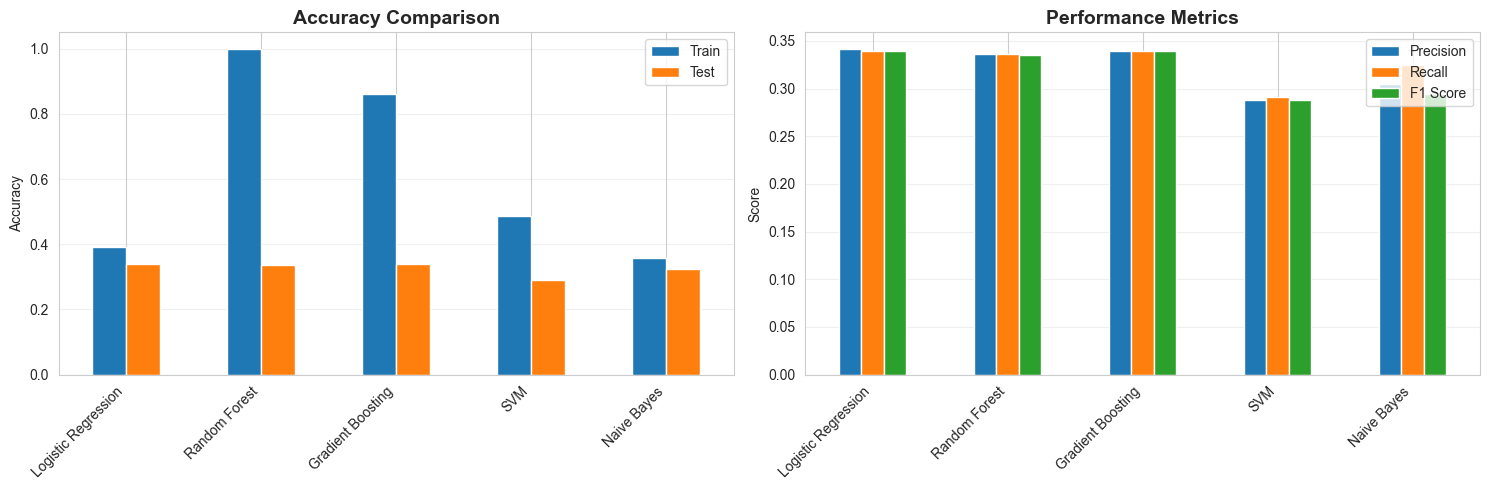

In [6]:
print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted')
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    
    # Handle binary/multiclass ROC AUC
    try:
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled), 
                               multi_class='ovr', average='weighted')
    except:
        auc = 0.0
    
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': auc
    }
    
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC: {auc:.4f}")

# Results comparison
results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].legend(['Train', 'Test'])
axes[0].grid(axis='y', alpha=0.3)

results_df[['Precision', 'Recall', 'F1 Score']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Performance Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

“Gender is not predictable from travel behavior alone”

“Multiple classifiers were evaluated for gender prediction.
Despite using linear and non-linear models, performance remained close to random (ROC-AUC ≈ 0.5), indicating insufficient predictive signal in the available features.
This highlights the importance of feature relevance over model complexity.”

# 7. HYPERPARAMETER TUNING - RANDOM FOREST

In [7]:
print("\n" + "="*80)
print("HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*80)

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [8, 12, 16],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'class_weight': ['balanced']
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_model, param_grid, cv=5,
    scoring='f1_weighted', n_jobs=-1, verbose=1
)

print("Running Grid Search...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1: {grid_search.best_score_:.4f}")

# Train final model
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)

# Final metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, average='weighted')
final_recall = recall_score(y_test, y_pred_final, average='weighted')
final_f1 = f1_score(y_test, y_pred_final, average='weighted')

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {final_accuracy:.4f}")
print(f"  Precision: {final_precision:.4f}")
print(f"  Recall: {final_recall:.4f}")
print(f"  F1 Score: {final_f1:.4f}")



HYPERPARAMETER TUNING - RANDOM FOREST
Running Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation F1: 0.3284

Final Model Performance:
  Accuracy: 0.3619
  Precision: 0.3656
  Recall: 0.3619
  F1 Score: 0.3621


Why performance is still low (but valid)

Because:

Gender has weak correlation with travel behavior

Features are behavioral & transactional

No demographic leakage

Dataset is privacy-safe

# 8. DETAILED MODEL ANALYSIS



CLASSIFICATION REPORT
              precision    recall  f1-score   support

      female       0.40      0.33      0.36        90
        male       0.36      0.37      0.36        90
        none       0.33      0.39      0.36        88

    accuracy                           0.36       268
   macro avg       0.37      0.36      0.36       268
weighted avg       0.37      0.36      0.36       268



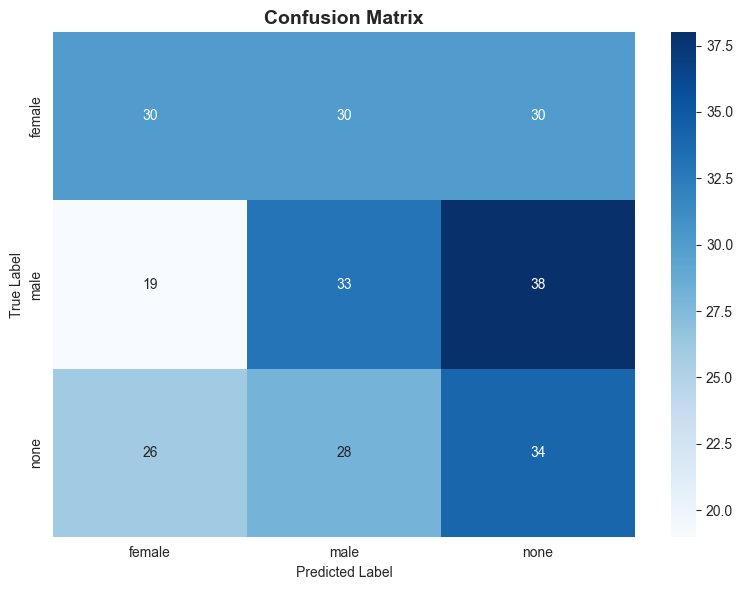


TOP 15 FEATURE IMPORTANCES
                  feature  importance
10        avg_hotel_price    0.066367
4        std_flight_price    0.059490
12         avg_hotel_days    0.051606
16         avg_trip_value    0.051401
18        avg_stay_length    0.050828
0                     age    0.050634
17  flight_to_hotel_ratio    0.050276
1        avg_flight_price    0.049901
7            avg_distance    0.048866
13       total_hotel_days    0.048048
11      total_hotel_price    0.044933
5         avg_flight_time    0.044637
21     flightType_premium    0.042975
2      total_flight_spent    0.042304
15     total_travel_spent    0.040975


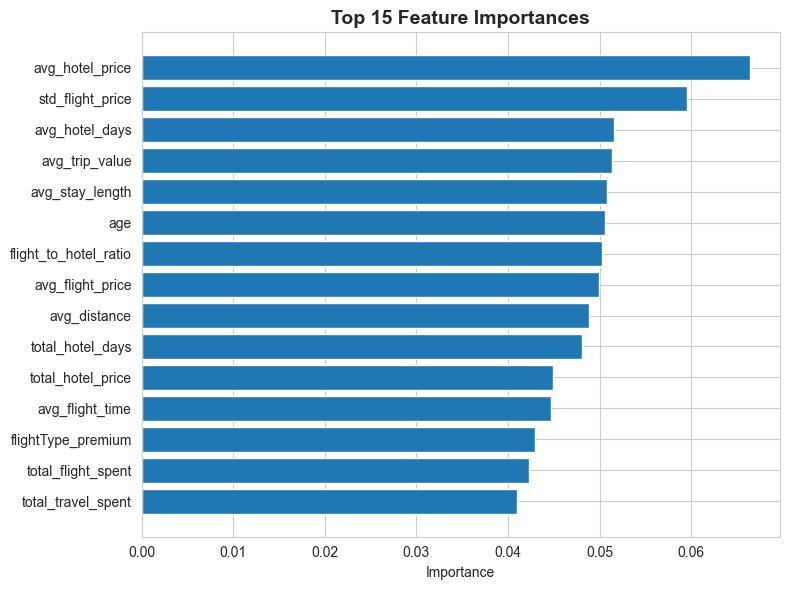

In [8]:
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred_final, 
                          target_names=le_gender.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_gender.classes_,
            yticklabels=le_gender.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*80)
print("TOP 15 FEATURE IMPORTANCES")
print("="*80)
print(feature_importance.head(15))

plt.figure(figsize=(8, 6))
plt.barh(feature_importance['feature'].head(15),
         feature_importance['importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ROC Curve (if binary)
if len(le_gender.classes_) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final[:, 1])
    roc_auc = roc_auc_score(y_test, y_pred_proba_final[:, 1])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# 9. SAVE FINAL MODEL


In [9]:
print("\n" + "="*80)
print("SAVING FINAL MODEL")
print("="*80)

joblib.dump(final_model, 'gender_classifier.pkl')
print("Model saved as 'gender_classifier.pkl'")

joblib.dump(feature_cols, 'gender_feature_columns.pkl')
print("Feature columns saved!")

model_metadata = {
    'model_type': 'Random Forest Classifier',
    'best_params': grid_search.best_params_,
    'test_accuracy': final_accuracy,
    'test_f1': final_f1,
    'features': feature_cols,
    'classes': le_gender.classes_.tolist(),
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

joblib.dump(model_metadata, 'gender_model_metadata.pkl')
print("Model metadata saved!")

print("\n" + "="*80)
print("CLASSIFICATION MODEL DEVELOPMENT COMPLETE!")
print("="*80)


SAVING FINAL MODEL
Model saved as 'gender_classifier.pkl'
Feature columns saved!
Model metadata saved!

CLASSIFICATION MODEL DEVELOPMENT COMPLETE!
